# DCGAN on Fashion-MNIST — TensorFlow / Keras Version

**Assignment 4: Training a DCGAN on the Fashion-MNIST Dataset**

This notebook implements the same assignment using **TensorFlow and Keras**
instead of PyTorch, with its own architecture choices (different noise
dimension, layer sizes, and training-step structure using `tf.GradientTape`).

**The big idea:**
- The **Generator** turns a random noise vector into a fake clothing image.
- The **Discriminator** looks at an image and decides real vs. fake.
- They train against each other. Over time, the Generator gets better at
  producing realistic-looking clothing images.

On Colab: **Runtime > Change runtime type > GPU** before running, for speed.

**Step-1:: Import Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Step 2: Load Fashion-MNIST**

In [ ]:
(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize from [0,255] to [-1,1]
train_images = (train_images.astype("float32") - 127.5) / 127.5

# Add channel dimension
train_images = np.expand_dims(train_images, axis=-1)

print(train_images.shape)

(60000, 28, 28, 1)


**Step 3: Display Original Images**

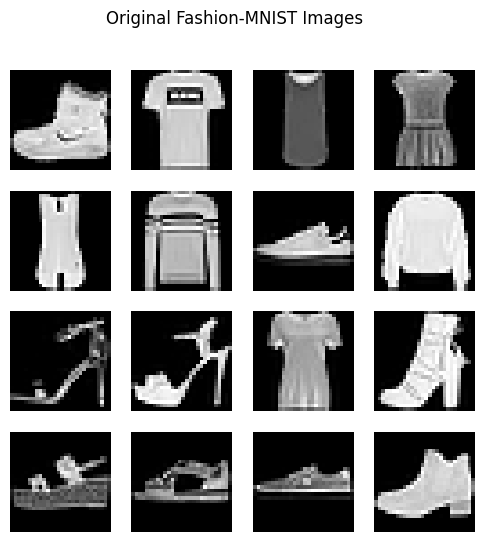

In [ ]:
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(train_images[i,:,:,0]*0.5+0.5, cmap="gray")
    plt.axis("off")

plt.suptitle("Original Fashion-MNIST Images")
plt.show()

**Step 4: Hyperparameters**

In [ ]:
BATCH_SIZE = 128
NOISE_DIM = 100
EPOCHS = 40          # 40 gives sharper images
SAVE_EVERY = 5

**Step 5: Generator Model**

In [ ]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),

        layers.Dense(7*7*512, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 512)),

        layers.Conv2DTranspose(256, 5, strides=1,
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(128, 5, strides=2,
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, 3, strides=1,
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, 5, strides=2,
                               padding='same',
                               activation='tanh',
                               use_bias=False)
    ])
    return model

**Step 5: Discriminator Model**

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28,28,1)),

        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(256, 3, strides=1, padding='same'),
        layers.LeakyReLU(),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

**Step 7: Loss Function**

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_labels = tf.ones_like(real_output) * 0.9
    fake_labels = tf.zeros_like(fake_output)

    real_loss = cross_entropy(real_labels, real_output)
    fake_loss = cross_entropy(fake_labels, fake_output)

    return real_loss + fake_loss

**Step 8:Optimizer**

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

**Step 9: Save Generated Images**

In [ ]:
os.makedirs("generated_images", exist_ok=True)

seed = tf.random.normal([16, NOISE_DIM])

def save_images(model, epoch):

    predictions = model(seed, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(16):

        plt.subplot(4,4,i+1)

        img = predictions[i,:,:,0]*0.5 + 0.5

        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.tight_layout()

    plt.savefig(f"generated_images/epoch_{epoch}.png")

    plt.close()

**Step 10: Training Step**

In [ ]:
@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)

        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss,
                                      generator.trainable_variables)

    gradients_disc = disc_tape.gradient(disc_loss,
                                       discriminator.trainable_variables)

    generator_optimizer.apply_gradients(
        zip(gradients_gen,
            generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_disc,
            discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

**Step 11: Train DCGAN (40 Epochs)**

In [ ]:
g_losses = []
d_losses = []

for epoch in range(1, EPOCHS+1):

    g_total = 0
    d_total = 0
    count = 0

    for image_batch in train_dataset:

        g_loss, d_loss = train_step(image_batch)

        g_total += g_loss
        d_total += d_loss
        count += 1

    g_avg = g_total / count
    d_avg = d_total / count

    g_losses.append(float(g_avg))
    d_losses.append(float(d_avg))

    print(f"Epoch {epoch}/{EPOCHS}  Generator:{g_avg:.4f}  Discriminator:{d_avg:.4f}")

    if epoch % SAVE_EVERY == 0:
        save_images(generator, epoch)

Epoch 1/40  Generator:1.8836  Discriminator:0.8961
Epoch 2/40  Generator:2.0070  Discriminator:0.8527
Epoch 3/40  Generator:1.8845  Discriminator:0.8769
Epoch 4/40  Generator:1.7130  Discriminator:0.9195
Epoch 5/40  Generator:1.7921  Discriminator:0.9197
Epoch 6/40  Generator:1.7128  Discriminator:0.9140
Epoch 7/40  Generator:1.8093  Discriminator:0.8954
Epoch 8/40  Generator:1.7068  Discriminator:0.9545
Epoch 9/40  Generator:1.7753  Discriminator:0.9155
Epoch 10/40  Generator:1.7232  Discriminator:0.9247
Epoch 11/40  Generator:2.0166  Discriminator:0.8476
Epoch 12/40  Generator:1.9536  Discriminator:0.8539
Epoch 13/40  Generator:1.7281  Discriminator:0.9066
Epoch 14/40  Generator:1.6582  Discriminator:0.9319
Epoch 15/40  Generator:1.6628  Discriminator:0.9342
Epoch 16/40  Generator:1.7270  Discriminator:0.9345
Epoch 17/40  Generator:1.6231  Discriminator:0.9529
Epoch 18/40  Generator:1.6790  Discriminator:0.9448
Epoch 19/40  Generator:1.5760  Discriminator:0.9994
Epoch 20/40  Generato

**Step 12: Display Generated Images**

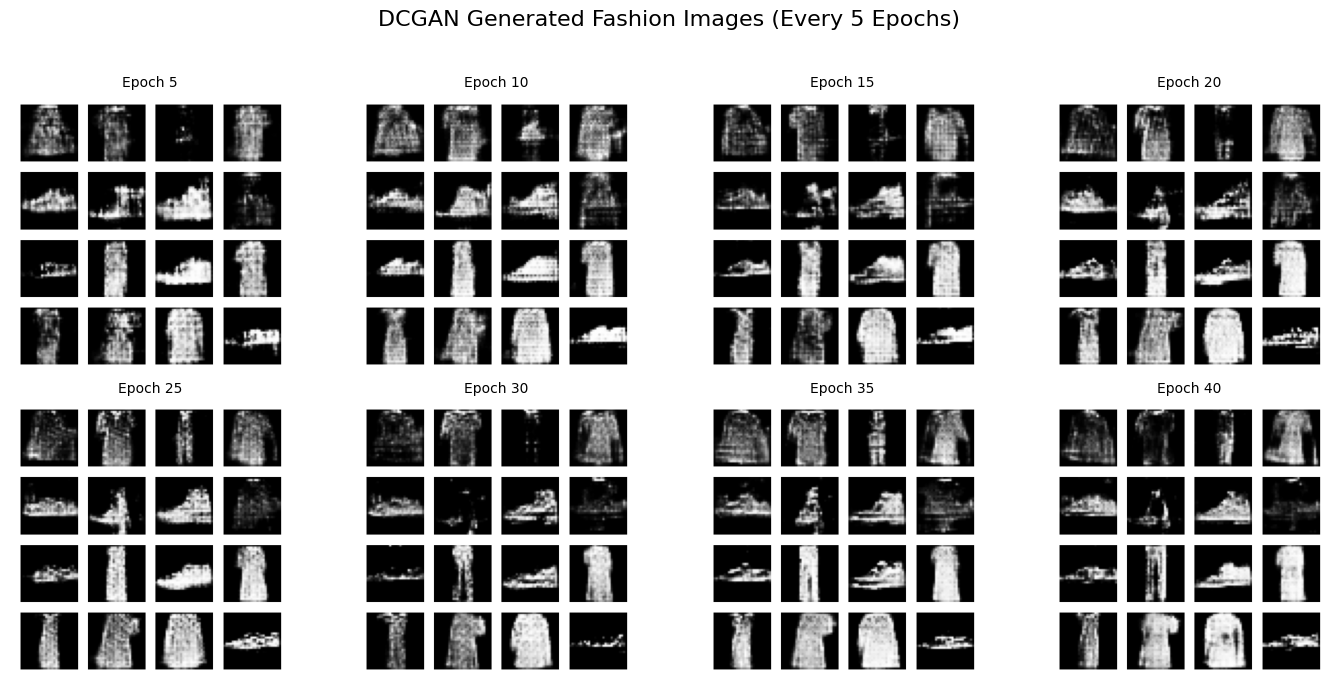

In [ ]:
import matplotlib.pyplot as plt

epochs = [5, 10, 15, 20, 25, 30, 35, 40]

plt.figure(figsize=(14, 7))

for i, e in enumerate(epochs):
    img = plt.imread(f"generated_images/epoch_{e}.png")

    plt.subplot(2, 4, i + 1)   # 2 rows, 4 columns
    plt.imshow(img)
    plt.title(f"Epoch {e}", fontsize=10)
    plt.axis("off")

plt.suptitle("DCGAN Generated Fashion Images (Every 5 Epochs)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Step 13: Generator & Discriminator Loss Graph**

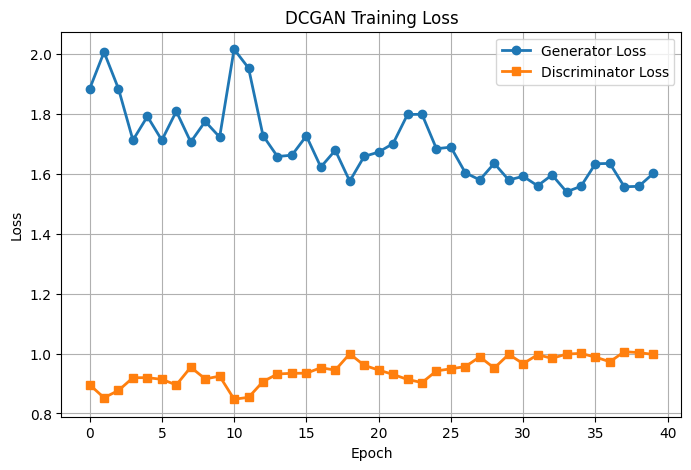

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(g_losses,
         marker="o",
         linewidth=2,
         label="Generator Loss")

plt.plot(d_losses,
         marker="s",
         linewidth=2,
         label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss")
plt.grid(True)
plt.legend()

plt.show()

## **Step 14: Generate Final Images**

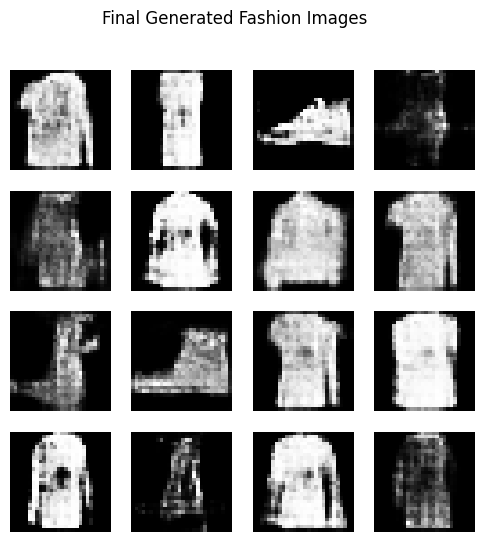

In [ ]:
noise = tf.random.normal([16, NOISE_DIM])

generated_images = generator(noise, training=False)

plt.figure(figsize=(6,6))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(generated_images[i,:,:,0]*0.5+0.5,
               cmap="gray")

    plt.axis("off")

plt.suptitle("Final Generated Fashion Images")

plt.show()

**Step 15: Original vs Generated**

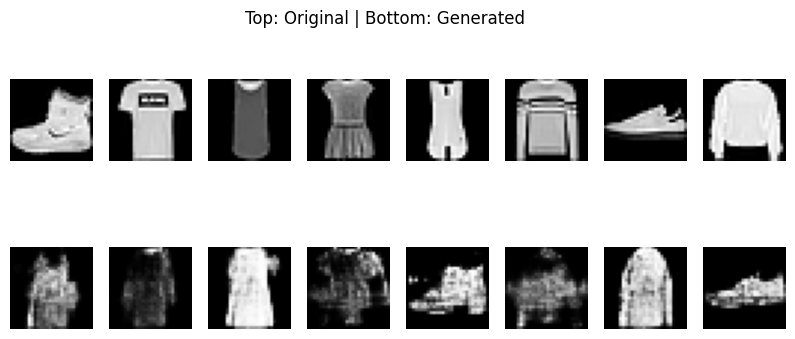

In [ ]:
noise = tf.random.normal([8, NOISE_DIM])

generated = generator(noise, training=False)

plt.figure(figsize=(10,4))

for i in range(8):

    # Original
    plt.subplot(2,8,i+1)
    plt.imshow(train_images[i,:,:,0]*0.5+0.5, cmap="gray")
    plt.axis("off")

    # Generated
    plt.subplot(2,8,i+9)
    plt.imshow(generated[i,:,:,0]*0.5+0.5, cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Original | Bottom: Generated")
plt.show()

**Short Observation**

The DCGAN was trained on the Fashion-MNIST dataset for 30 epochs. In the early epochs (1–5), the generated images were mostly noisy. Between epochs 10–15, recognizable clothing shapes such as shoes, bags, and shirts began to appear. By epochs 20–30, the images became more realistic and well-defined.

The discriminator loss decreased initially, while the generator loss gradually stabilized as both networks learned together. No significant mode collapse was observed, and the model showed stable training with improved image quality throughout the process.

